In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import spearmanr
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers

# 1. Filtering data to tiles appropriate for fit

In [2]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
#dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_end", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
activities = activities.rename(columns = {"mean" : "activity"})
activities["error"] = (activities["ci_hi"] - activities["ci_low"]) / (2 * 1.96)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,ns,0.339729
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,ns,0.265582
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,activator,0.170569
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,ns,0.256423
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,ns,0.368413
...,...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,2,ns,0.393616
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,2,ns,0.166536
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,2,ns,0.254877
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,2,ns,0.047173


In [3]:
activities = activities[activities["time"] <= 30]
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,ns,0.339729
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,ns,0.265582
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,activator,0.170569
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,ns,0.256423
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,ns,0.368413
...,...,...,...,...,...,...,...,...
27549,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,0,0.182490,-0.216894,0.602357,2,ns,0.208992
27550,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,5,-0.093504,-0.346717,0.105645,2,ns,0.115398
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,2,ns,0.393616
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,2,ns,0.166536


In [4]:
activities["ADseq"].value_counts()

ADseq
AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS    5
AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK    5
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
                                           ..
TSPDINDSPFNDSFDCSPMFQNEPTMANSDWFSLFPEEET    1
TSSPPSGTHSSVSGVNSRKRDKPLPPIIVEDPNDTIAMKR    1
VKSPMEVPADLEITETDSLPRRKSSNSPSSSHGHGRHSSV    1
WLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFVKSL    1
WYSLFPETNPDPEDSVSPPMPNIPQTDALIGDQSGRLDEE    1
Name: count, Length: 4042, dtype: int64

In [5]:
# get last timepoint per ADseq
last = (
    activities.sort_values("time")
      .groupby("ADseq")
      .tail(1)
)

# find ADseqs where the last time point is active
keep_adseq = (
    last.groupby("ADseq")["class"]
    .apply(lambda x: (x == "activator").any())
)

# filter original df
active_tile_activities = activities[activities["ADseq"].isin(keep_adseq[keep_adseq].index)]
active_tile_activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013
...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373


In [6]:
active_tile_activities["ADseq"].value_counts()

ADseq
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT    5
                                           ..
HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL    4
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
NDFDTTVLSPQQFSTAGLGPVPDSIAGAPSGTISPQDLMM    4
SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ    4
YDPHMNLSSSSSTNMGTVSPQDLLRDPFPSAPNSTAFTNL    4
Name: count, Length: 1709, dtype: int64

In [21]:
expected = active_tile_activities["time"].unique()

def ok(grp):
    t = set(grp["time"].unique())

    missing = [x for x in expected if x not in t]

    if len(missing) > 1: # Want at least 4 time points
        return False

    if len(missing) <= 1:
        return True

    # check if missing are isolated in the expected sequence
    idx = np.where(np.isin(expected, missing))[0]

    # if indices are consecutive → bad
    if len(idx) > 1 and np.any(np.diff(idx) == 1):
        return False

    return True

active_tile_activities_count_filtered = active_tile_activities.groupby("ADseq").filter(ok)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013
...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373


In [22]:
active_tile_activities_count_filtered["ADseq"].value_counts()

ADseq
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT    5
                                           ..
HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL    4
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
NDFDTTVLSPQQFSTAGLGPVPDSIAGAPSGTISPQDLMM    4
SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ    4
YDPHMNLSSSSSTNMGTVSPQDLLRDPFPSAPNSTAFTNL    4
Name: count, Length: 1709, dtype: int64

In [23]:
# --- further filter to ensure time=0 exists ---
active_tile_activities_count_filtered = active_tile_activities_count_filtered.groupby('ADseq').filter(lambda x: 0 in x['time'].values)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013
...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373


In [24]:
active_tile_activities_count_filtered["ADseq"].value_counts()

ADseq
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT    5
                                           ..
HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL    4
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
NDFDTTVLSPQQFSTAGLGPVPDSIAGAPSGTISPQDLMM    4
SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ    4
YDPHMNLSSSSSTNMGTVSPQDLLRDPFPSAPNSTAFTNL    4
Name: count, Length: 1709, dtype: int64

In [25]:
activities_norm = active_tile_activities_count_filtered.copy()

# map time=0 activity per ADseq directly
baseline = activities_norm[activities_norm["time"] == 0].set_index("ADseq")["activity"]
activities_norm["activity_norm"] = (activities_norm["activity"] - activities_norm["ADseq"].map(baseline)).clip(lower=0)

#activities_norm = activities_norm.drop(columns = ["activity_0"])
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488
...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066


In [26]:
activities_norm["ci_low_norm"] = activities_norm["ci_low"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm["ci_hi_norm"] = activities_norm["ci_hi"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


In [27]:
activities_norm.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv")

# Baseline activity over time

100%|██████████| 4/4 [00:00<00:00, 47.68it/s]


(<Figure size 2400x3600 with 4 Axes>,
 array([<Axes: ylabel='5 min.'>, <Axes: ylabel='10 min.'>,
        <Axes: ylabel='15 min.'>, <Axes: ylabel='30 min.'>], dtype=object))

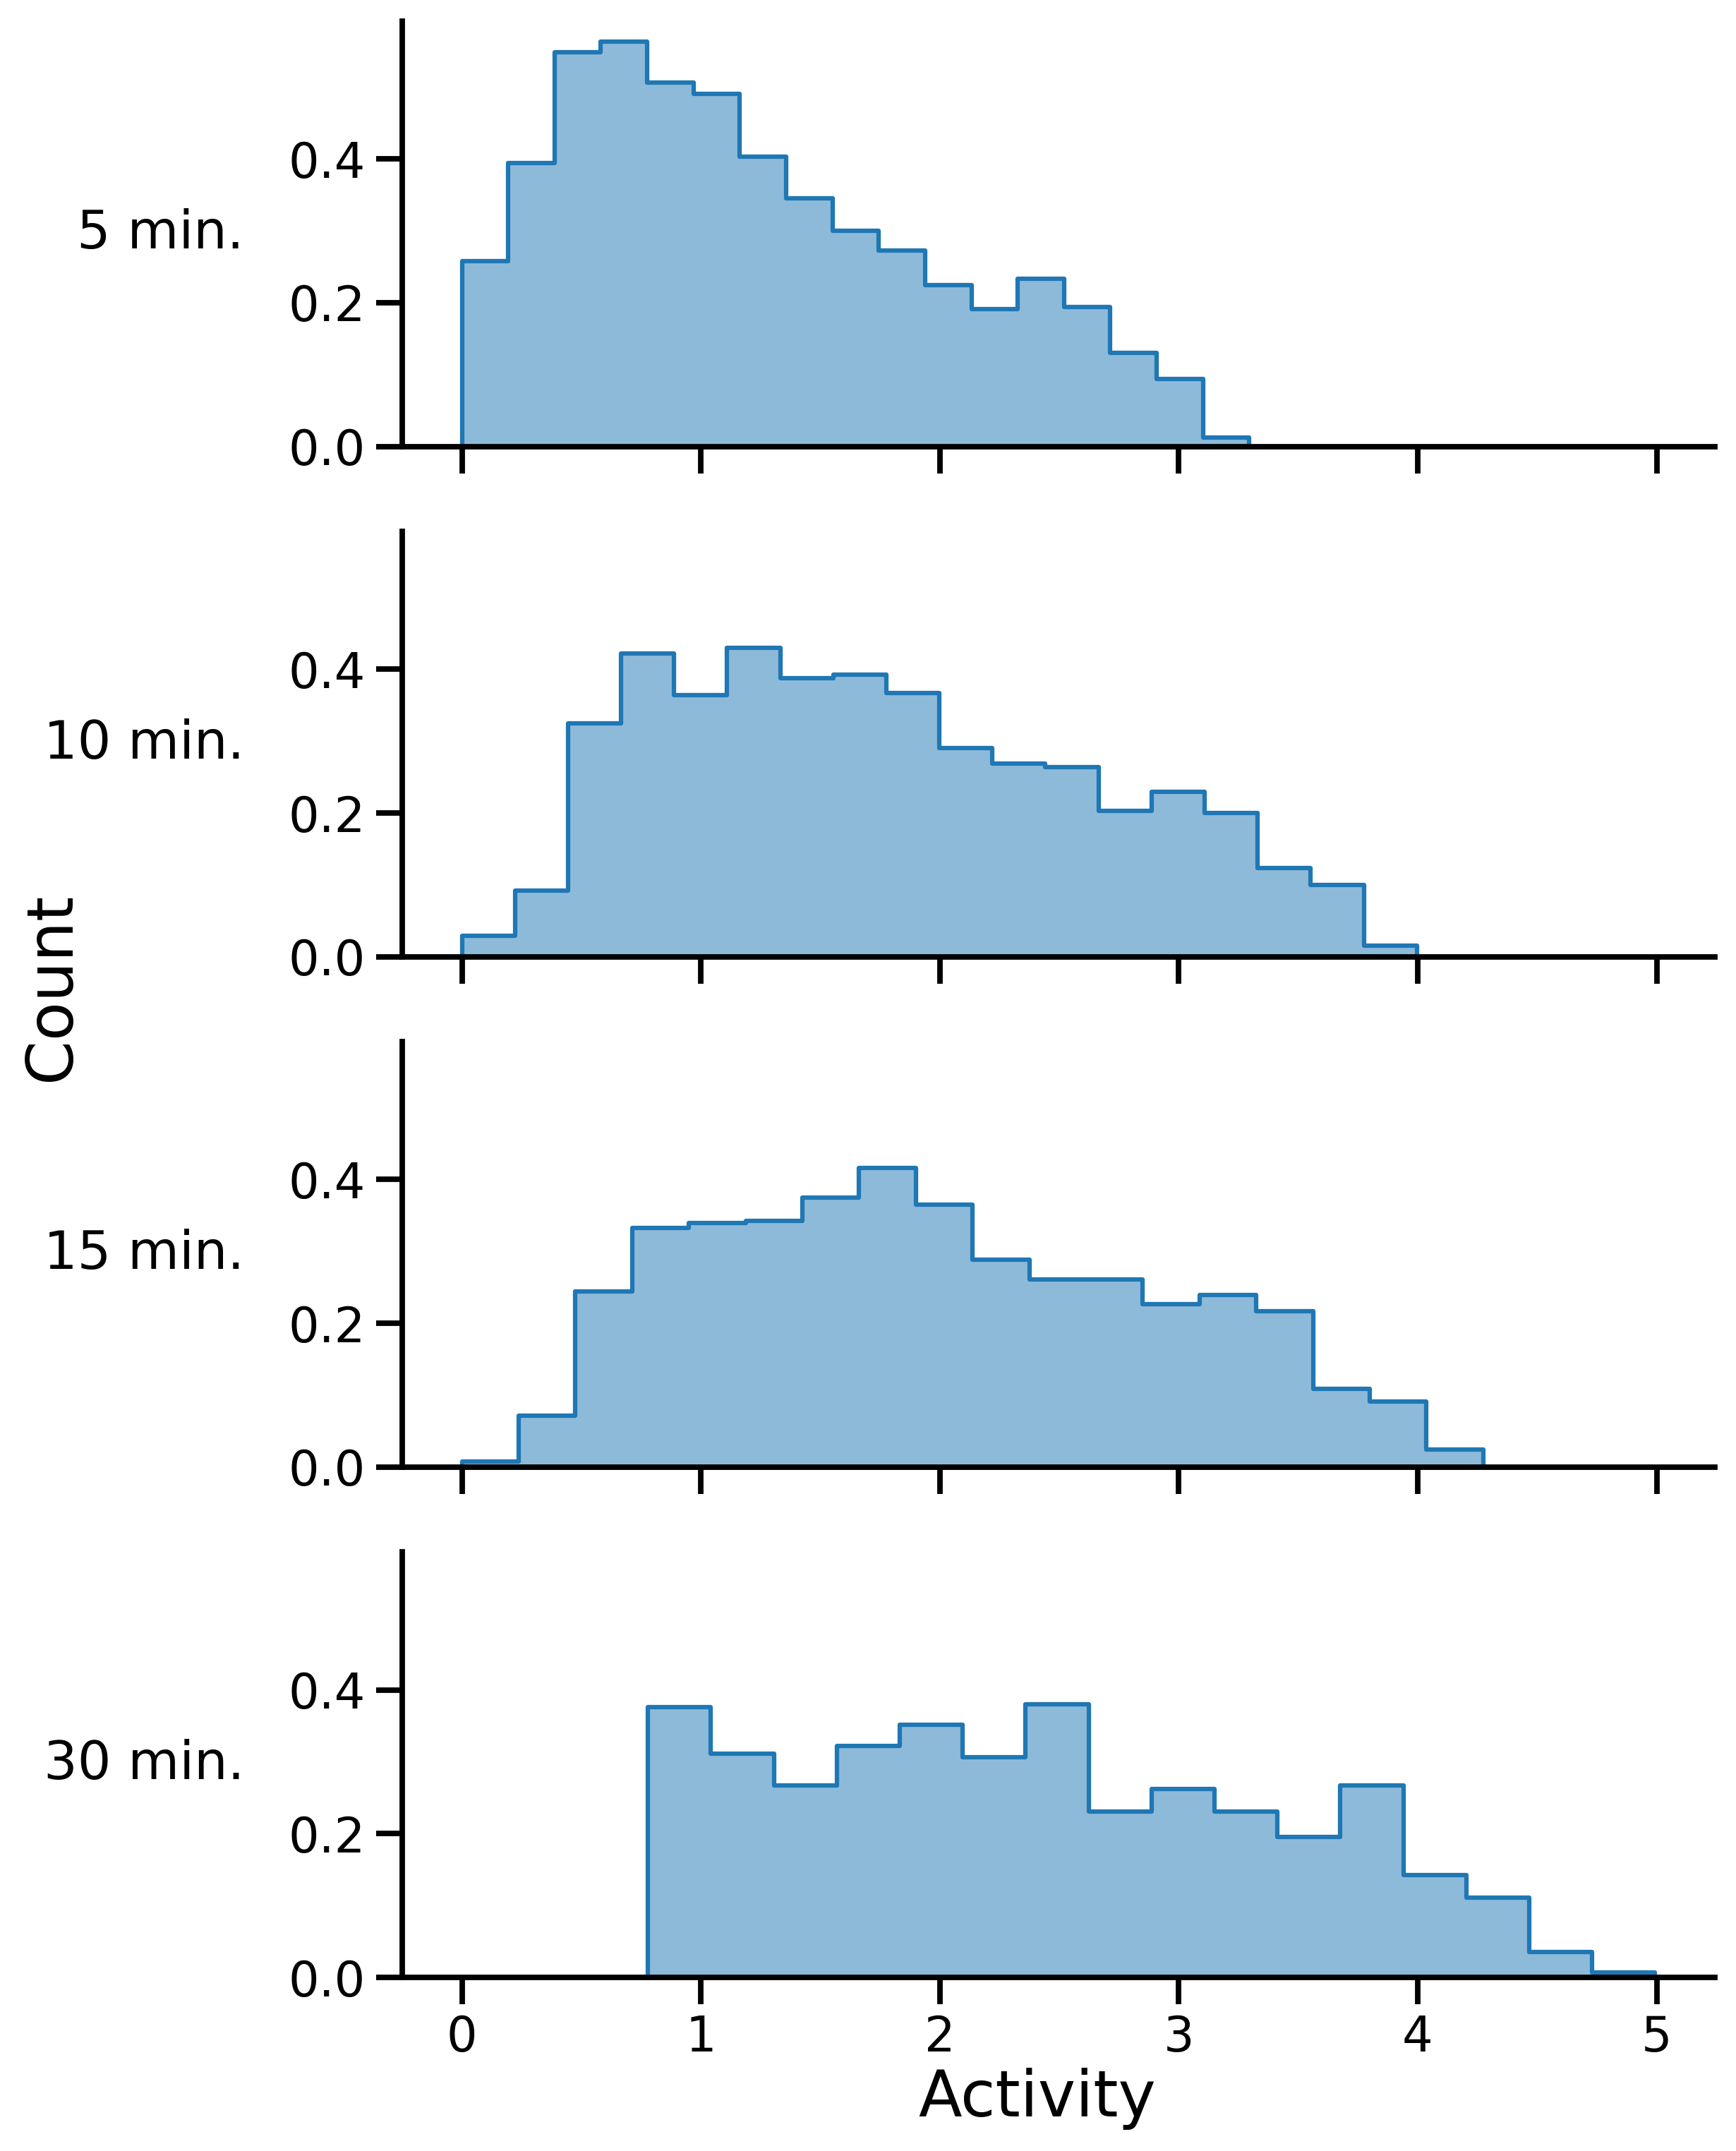

In [14]:
time_normalization_helpers.plot_hists_over_time(activities_norm[activities_norm["time"] != 0], column = "activity_norm")

# 2. plotting raw vs baseline activities

In [15]:
max_activities = activities_norm.groupby("ADseq")[["activity", "activity_norm"]].max().reset_index()
max_activities = pd.merge(max_activities, activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].rename(columns = {"activity" : "activity_t0"}))
max_activities

,ADseq,activity,activity_norm,activity_t0
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.813740,1.210488,0.603252
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.291359,2.359397,-0.068038
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.729031,2.032776,-0.303746
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.629833,2.527994,1.101839
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,0.749778,0.890615,-0.140837
...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,1.832128,1.469611,0.362517
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,1.065267,1.090644,-0.025377
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.331930,4.379672,0.952257
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.143501,2.794890,0.348611


Pearson r = 0.717
Spearman r = 0.707, p = 2.31e-259


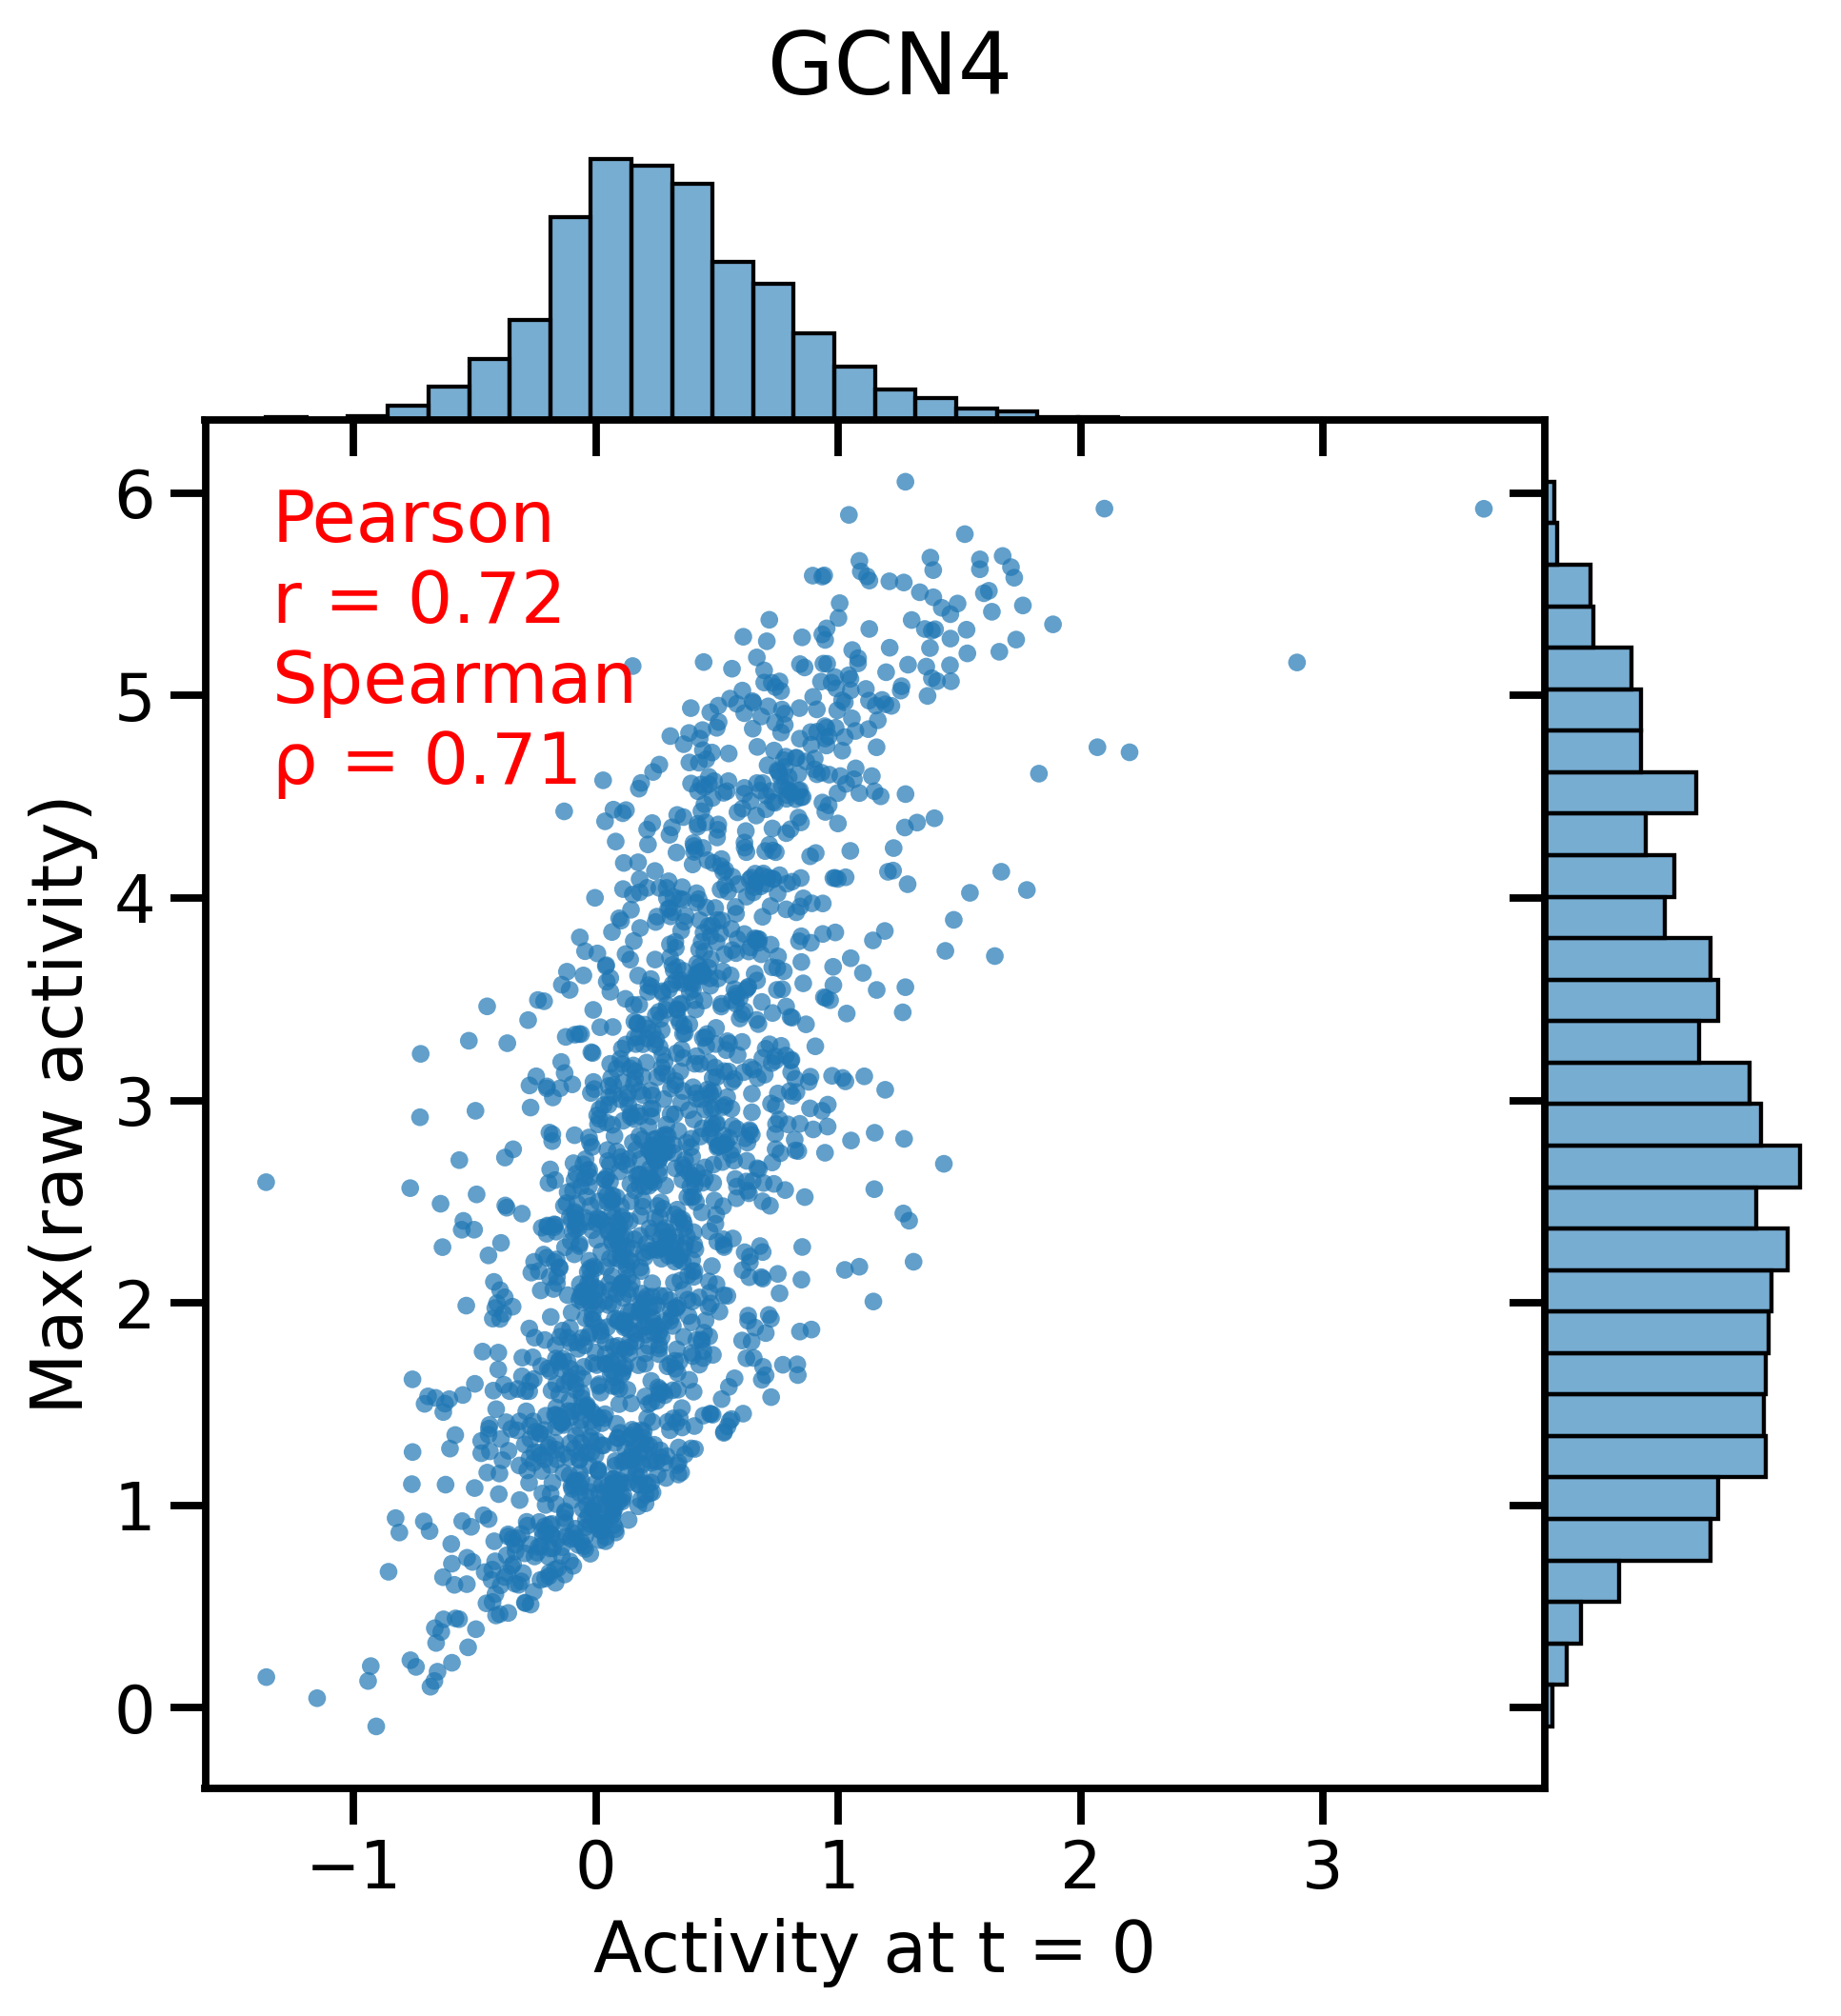

In [16]:
## Plotting
x = max_activities["activity_t0"]
y = max_activities["activity"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context('talk')

# joint plot with marginal histograms
g = sns.JointGrid(data=max_activities, x="activity_t0", y="activity", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor='none',
    s=20
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# labels
g.set_axis_labels("Activity at t = 0", "Max(raw activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha='left',
    va='top',
    color = 'red'
)

g.fig.set_dpi(300)
g.fig.suptitle("GCN4", y=1.02)

plt.show()

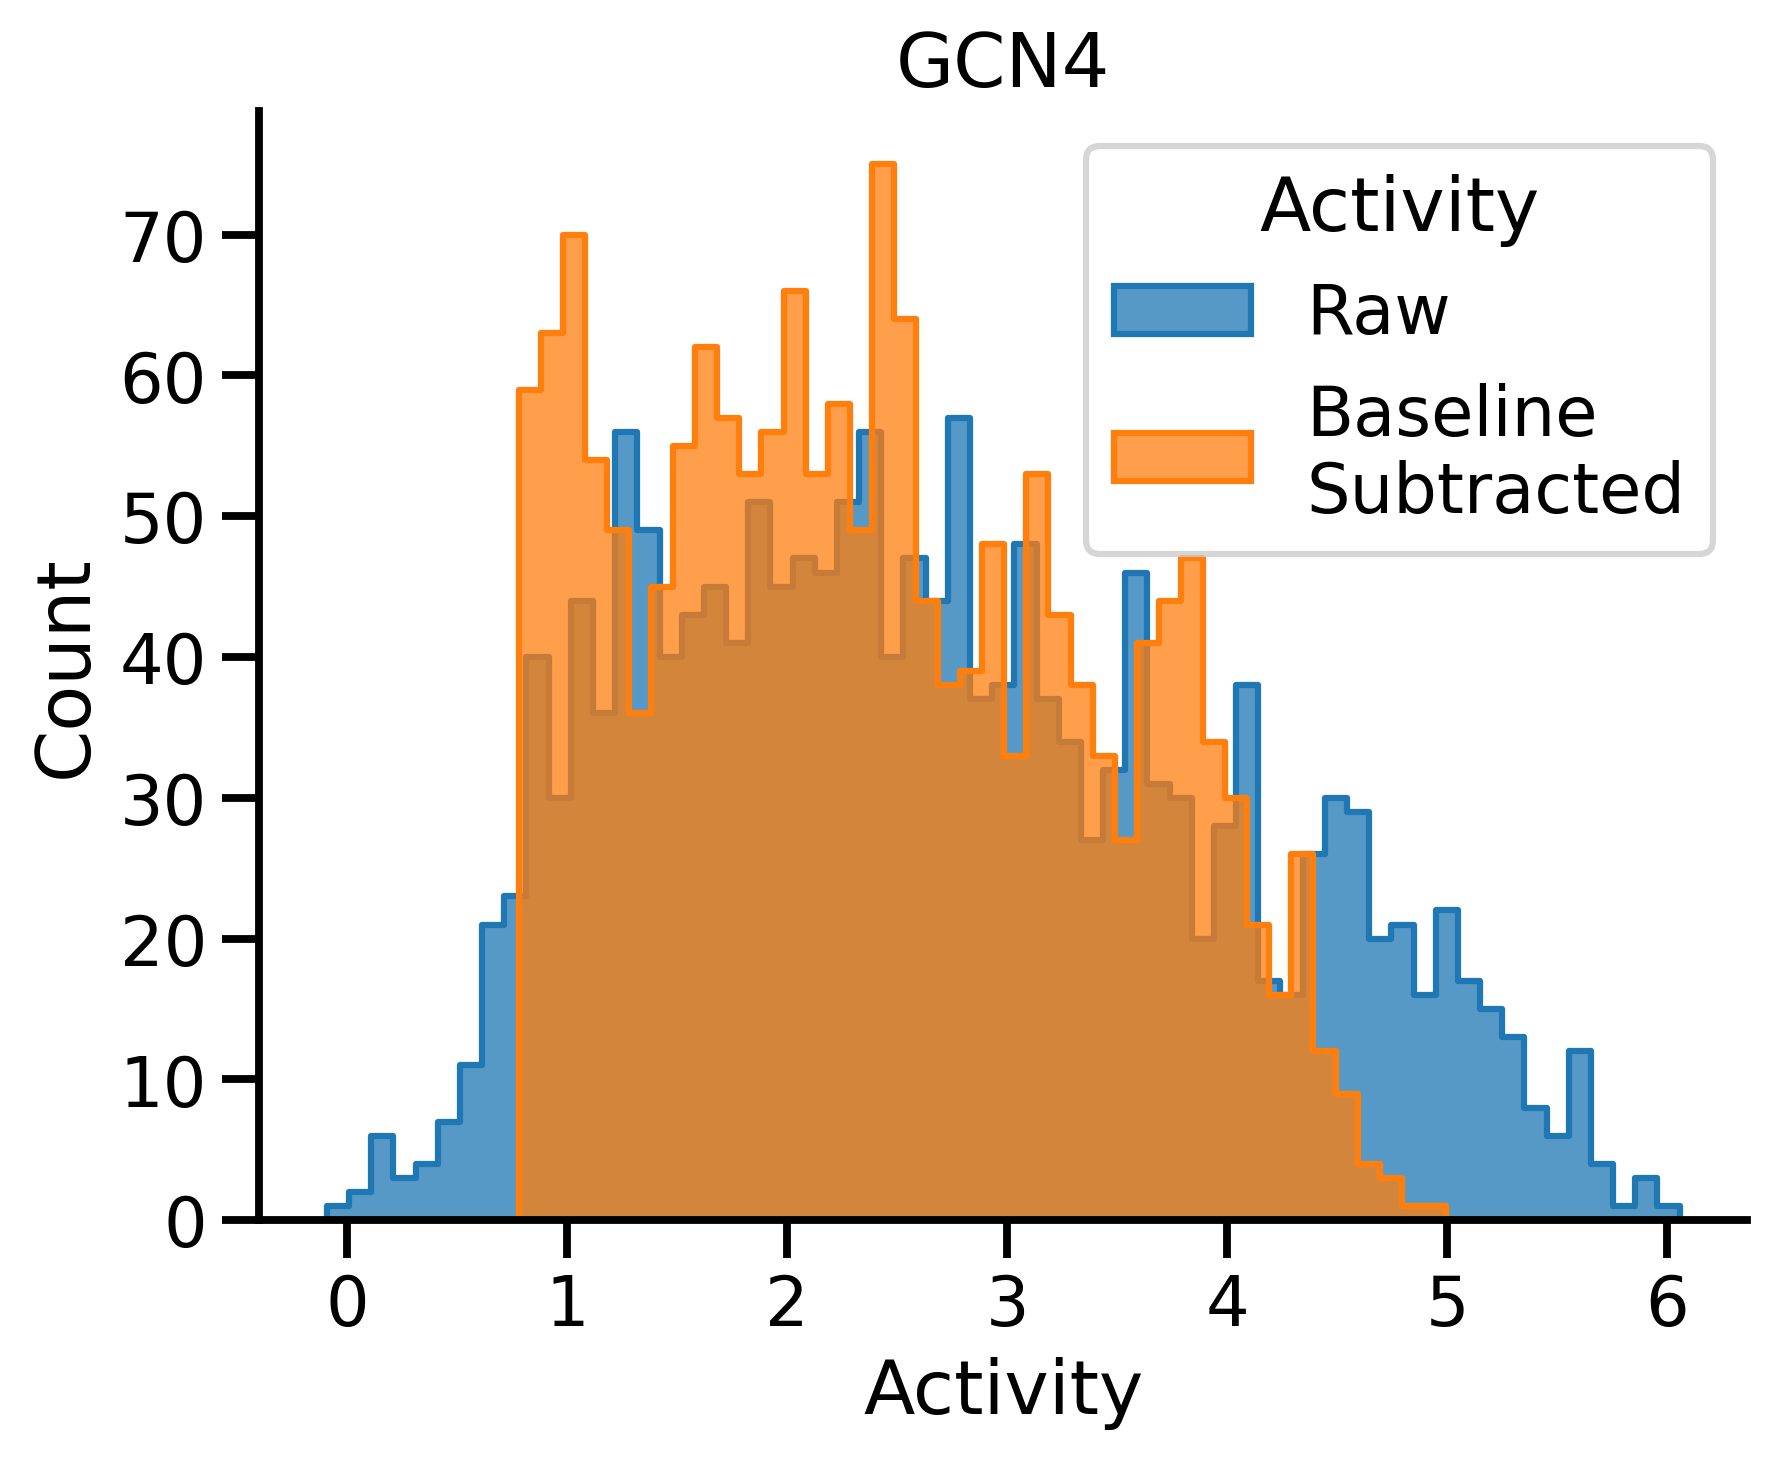

In [17]:
sns.set_context('talk')
plt.figure(dpi = 300)
plt.title("GCN4")
sns.histplot(data = max_activities, x = "activity", binwidth = 0.1, element ='step', label = "Raw")
sns.histplot(data = max_activities, x = "activity_norm", binwidth = 0.1, element ='step', label = "Baseline\nSubtracted")
plt.legend(title = "Activity")
plt.xlabel("Activity")
sns.despine()

Pearson r = 0.944
Spearman r = 0.949, p = 0.00e+00


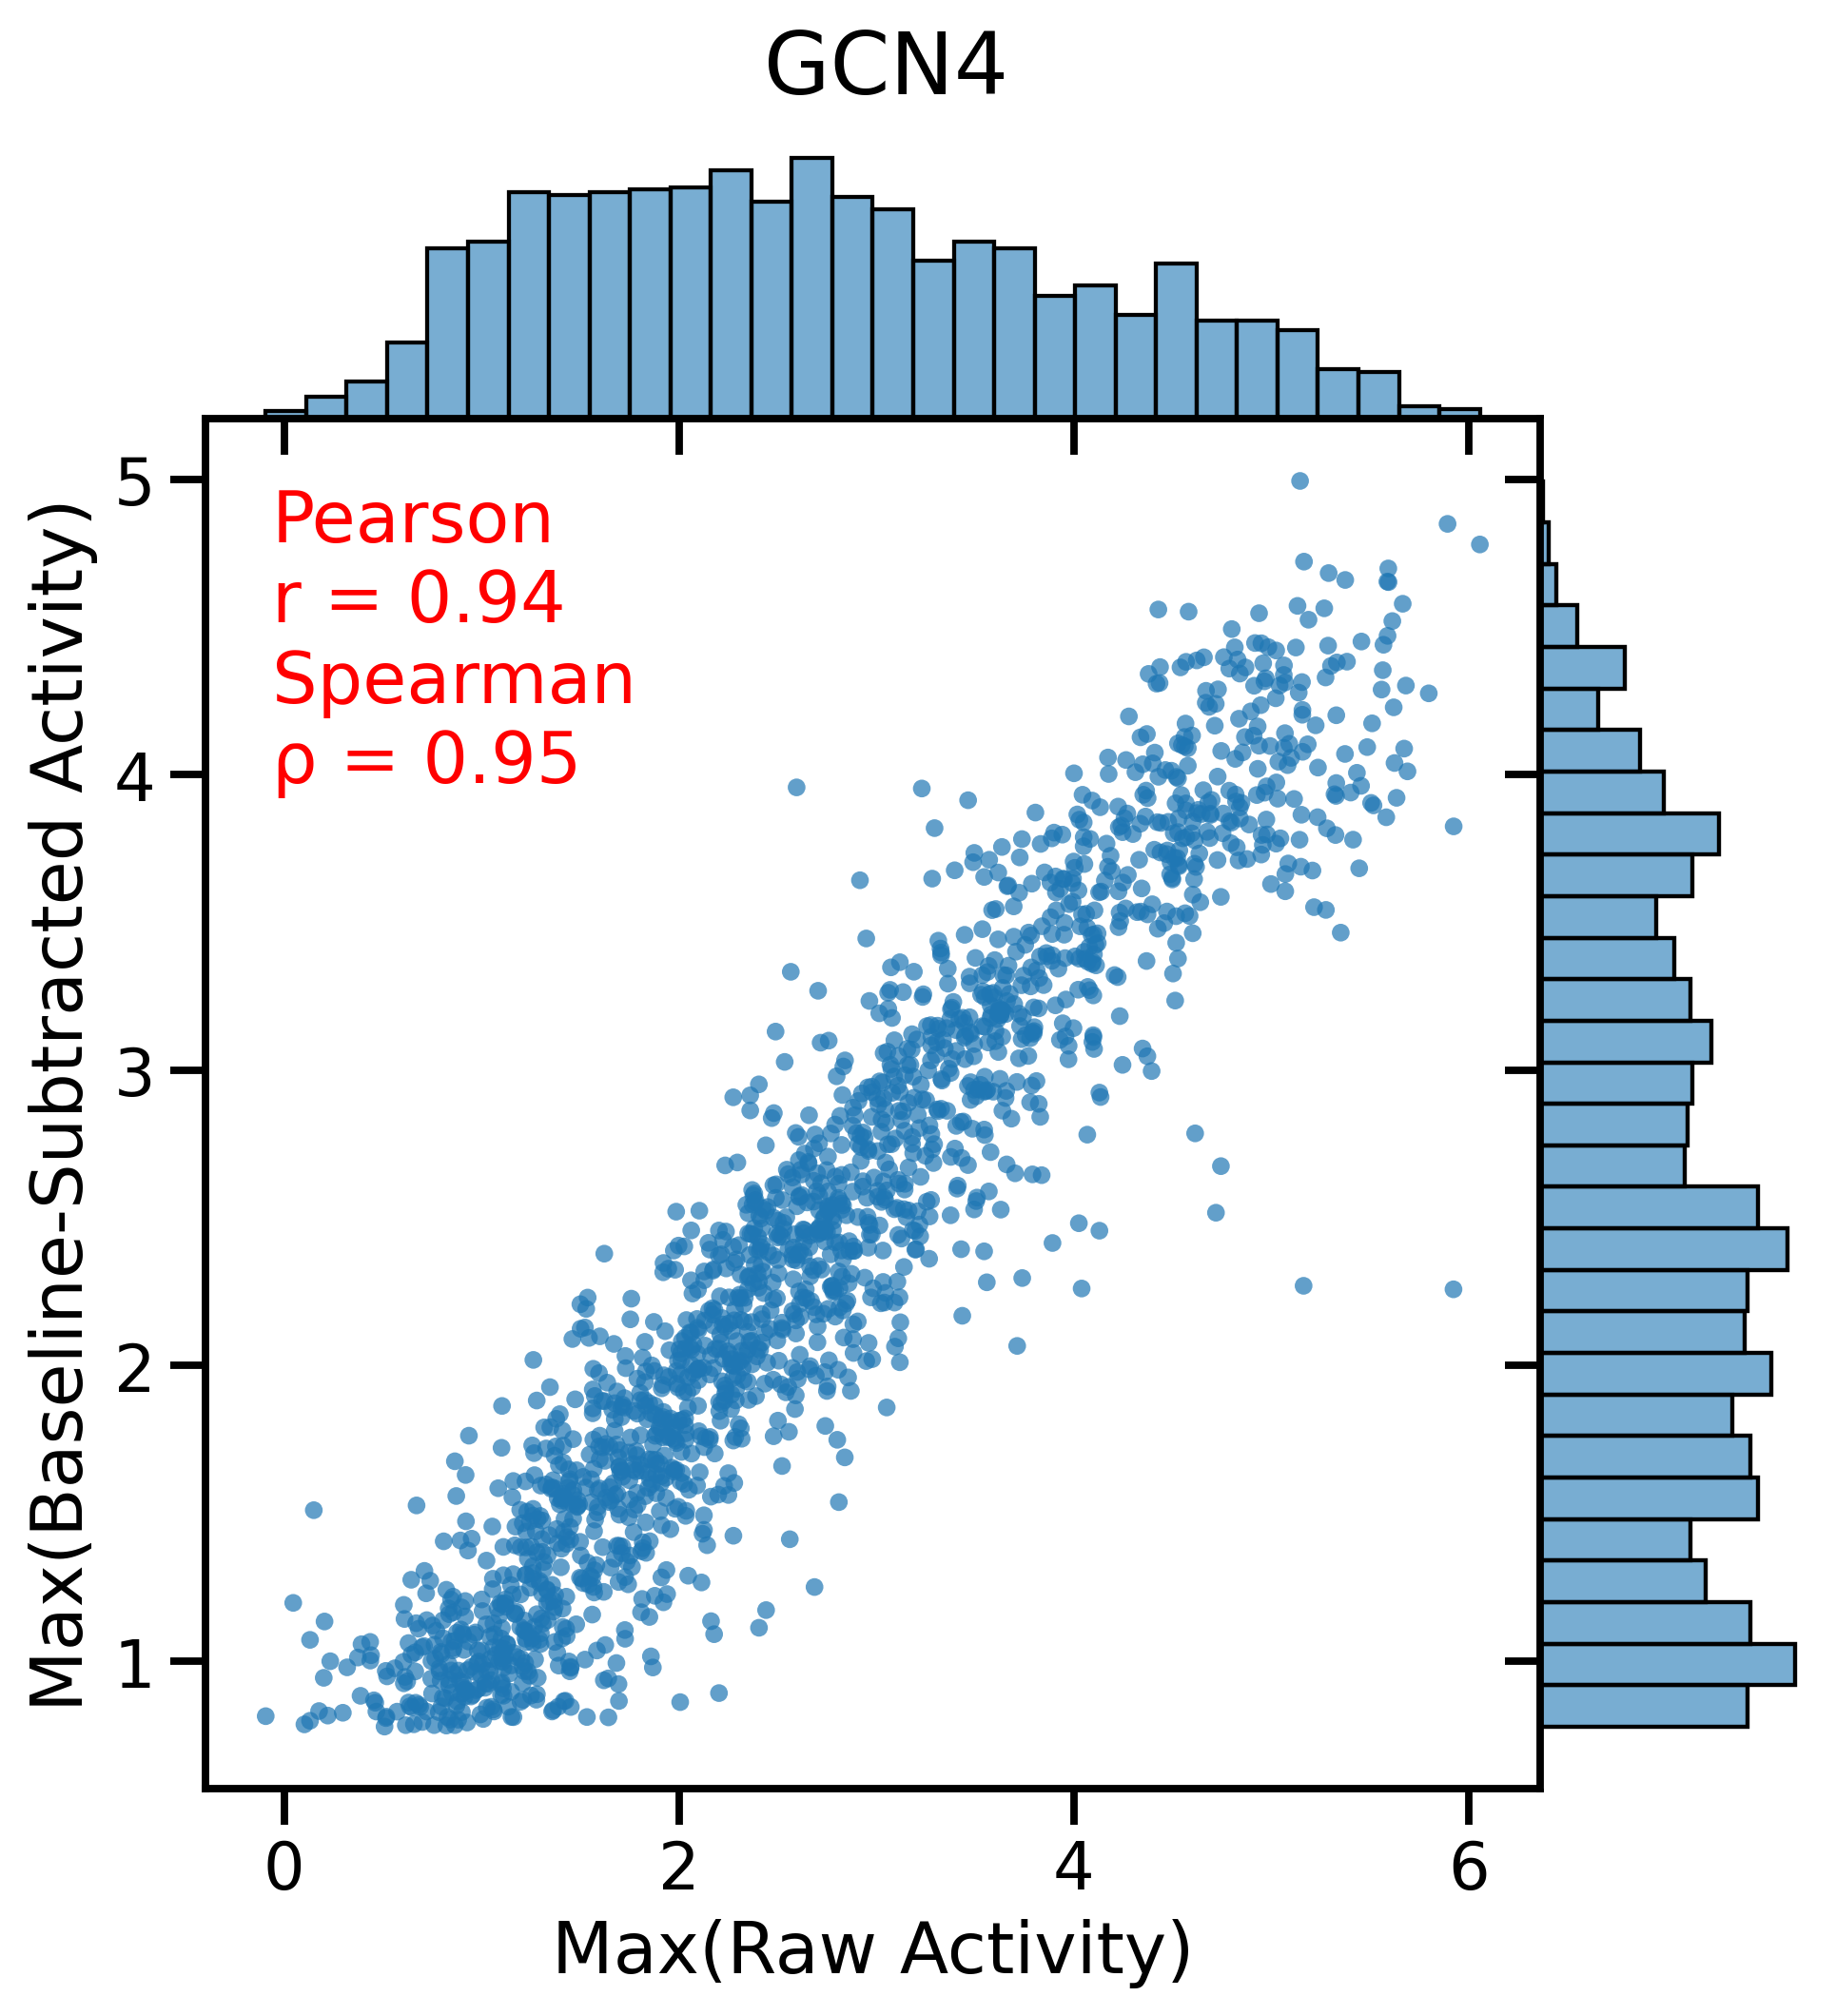

In [18]:
## Plotting

x = max_activities["activity"]
y = max_activities["activity_norm"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context("talk")

# joint plot
g = sns.JointGrid(data=max_activities, x="activity", y="activity_norm", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor="none",
    s=20
)

# marginals
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# identity line (perfect agreement)
max_val = max(x.max(), y.max())
#g.ax_joint.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=1)

# axis labels
g.set_axis_labels("Max(Raw Activity)", "Max(Baseline-Subtracted Activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha="left",
    va="top",
    color="red"
)

g.fig.set_dpi(300)
g.fig.suptitle("GCN4", y=1.02)

plt.show()